In [1]:
import os
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/ForceSMIP")

In [2]:
import pickle

############### Load climate model raw data for SST
with open('data/ssp585_time_series.pkl', 'rb') as f:
    data = pickle.load(f)

[-88.75 -86.25 -83.75 -81.25 -78.75] [ 1.25  3.75  6.25  8.75 11.25] (72, 144)


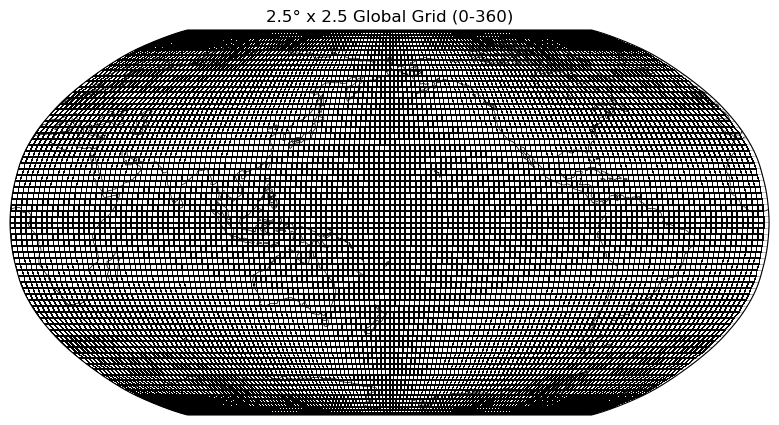

In [3]:
from ForceSMIP.utils import generate_grid_with_areas, plot_empty_grid
lat_c, lon_c, lat_e, lon_e, cell_areas = generate_grid_with_areas(res_deg=2.5, lon_domain="0-360")
print(lat_c[:5], lon_c[:5], cell_areas.shape)
fig = plot_empty_grid()
fig.savefig("figures/grid_2p5deg.png", dpi=200)


In [4]:
# Import our modules
from data_loader import ForceSMIPDataLoader
from preprocessing import (
    merge_training_data, reshape_training_data, 
    filter_training_dict_by_indices,filter_training_data_by_indices , capture_nans
)
from algorithms import WeightedRidgeRegression, ridge_regression, LowRankSolver
from evaluation import ForceSMIPEvaluator, compute_trends_from_data, compute_statistics
from visualization import ForceSMIPVisualizer
from forcesmip_pipeline import ForceSMIPPipeline
import torch
import numpy as np

# Set random seeds for reproducibility
np.random.seed(42)

print("Modules loaded successfully!")

Modules loaded successfully!


In [5]:
# reprocess the data by stacking all elements of each climate model
T = 165 # number of time steps
lon_size = 144 # number of longitude points
lat_size = 72 # number of latitude points

dic_data = {}
dic_forced_response = {}

for key in data.keys():
    if len(data[key].keys()) > 3:
        dic_data[key] = np.empty((1,T,lat_size,lon_size))  # Initialize an empty array with the correct shape
        for (key_m,item_m) in data[key].items():
            dic_data[key] = np.concatenate([dic_data[key], item_m.reshape(-1, item_m.shape[0], item_m.shape[1], item_m.shape[2])], axis=0)
        dic_data[key] = dic_data[key] - np.nanmean(dic_data[key], axis=1, keepdims=True)
        dic_forced_response[key] = np.nanmean(dic_data[key], axis=0, keepdims=True).repeat(dic_data[key].shape[0], axis=0)
    # print(f"{key} data centered. Shape: {dic_data[key].shape}, Mean after centering: {np.nanmean(dic_data[key])}")
    # print(f"{key} forced response computed. Shape: {dic_forced_response[key].shape}, Mean: {dic_forced_response[key]}")

/tmp/ipykernel_3335/402951601.py:14: RuntimeWarning: Mean of empty slice
  dic_data[key] = dic_data[key] - np.nanmean(dic_data[key], axis=1, keepdims=True)


In [6]:
# # Center the data by removing the temporal mean and compute the forced response
# dic_forced_response = {}

# for key in dic_data.keys():
#     print(key)
#     dic_data[key] = dic_data[key] - np.nanmean(dic_data[key], axis=1, keepdims=True)
#     dic_forced_response[key] = np.nanmean(dic_data[key], axis=0, keepdims=True)
#     # print(f"{key} data centered. Shape: {dic_data[key].shape}, Mean after centering: {np.nanmean(dic_data[key])}")
#     # print(f"{key} forced response computed. Shape: {dic_forced_response[key].shape}, Mean: {np.nanmean(dic_forced_response[key])}")

In [7]:
# Prepare training data for machine learning
print("Preparing training data...")

# Method 1: Merge all training data
x_train_merged, y_train_merged = merge_training_data(
    dic_data, dic_forced_response
)

# Method 2: Keep model separation
x_train_dict, y_train_dict = reshape_training_data(
    dic_data, dic_forced_response
)

print(f"Merged training data shape: X={x_train_merged.shape}, Y={y_train_merged.shape}")
print(f"Separated training data: {len(x_train_dict)} models")

Preparing training data...
Merged training data shape: X=torch.Size([123915, 10368]), Y=torch.Size([123915, 10368])
Separated training data: 34 models


In [8]:
# enumerate in the dictionary and get the union of the nans for each pair ((key, value))
for idx, (key, value) in enumerate(x_train_dict.items()):


    # new code to test
    # get nan mask of test set
    nan_mask = np.where(np.isnan(value)==True, True, False)


    # get the index of grid cells for which there is at least one Nans in other dimensions
    # print(np.sum(nan_mask,axis=(0,1)).shape)
    nan_idx = np.where(np.sum(nan_mask,axis=(0,1)) > 0)[0]
    print(f"NaN indices for {key}: {nan_idx}")
    print(f"Number of NaN indices for {key}: {len(nan_idx)}")

    # get the index of columns where there is at least one True in the nan mask
    if idx == 0:
        nan_union = set(nan_idx)
    else:
        nan_union = nan_union.union(set(nan_idx))

notnan_idx = list(set(range(value.shape[2])) - set(nan_union))
nan_idx = list(set(nan_union))

NaN indices for ICON-ESM-LR: [   0    1    2 ... 9905 9920 9921]
Number of NaN indices for ICON-ESM-LR: 1525


/tmp/ipykernel_3335/1184103525.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  nan_mask = np.where(np.isnan(value)==True, True, False)


NaN indices for EC-Earth3: [   0    1    2 ... 9927 9928 9929]
Number of NaN indices for EC-Earth3: 3262
NaN indices for CMCC-CM2-SR5: [   0    1    2 ... 9927 9928 9929]
Number of NaN indices for CMCC-CM2-SR5: 3250
NaN indices for ACCESS-CM2: [   0    1    2 ... 9927 9928 9929]
Number of NaN indices for ACCESS-CM2: 3310
NaN indices for CESM2: [    0     1     2 ...  9929  9930 10068]
Number of NaN indices for CESM2: 3329
NaN indices for CNRM-ESM2-1: [   0    1    2 ... 9927 9928 9929]
Number of NaN indices for CNRM-ESM2-1: 3262
NaN indices for IPSL-CM6A-LR: [   0    1    2 ... 9927 9928 9929]
Number of NaN indices for IPSL-CM6A-LR: 3233
NaN indices for GISS-E2-2-G: [    0     1     2 ...  9924  9925 10067]
Number of NaN indices for GISS-E2-2-G: 2714
NaN indices for CNRM-CM6-1: [   0    1    2 ... 9927 9928 9929]
Number of NaN indices for CNRM-CM6-1: 3262
NaN indices for CanESM5-1: [   0    1    2 ... 9927 9928 9929]
Number of NaN indices for CanESM5-1: 3250
NaN indices for E3SM-2-0-NA

In [9]:
# get list of integers
notnan_idx = [int(x) for x in notnan_idx]
nan_idx = [int(x) for x in nan_idx]


In [10]:
# nan_idx, notnan_idx =capture_nans(x_train_dict)

In [11]:
# Apply not-NaN filter to all data

x_train_dict_filtered, y_train_dict_filtered  = filter_training_dict_by_indices(x_train_dict,
                                   y_train_dict,
                                   notnan_idx,
                                   verbose = True) 
x_train_merged_filtered, y_train_merged_filtered = filter_training_data_by_indices(
        x_train_merged, y_train_merged, notnan_idx
    )

Filtering training dictionaries...
Keeping 6523 valid spatial features
torch.Size([6, 165, 10368])
ICON-ESM-LR: X torch.Size([6, 165, 10368]) -> torch.Size([6, 165, 6523])
torch.Size([24, 165, 10368])
EC-Earth3: X torch.Size([24, 165, 10368]) -> torch.Size([24, 165, 6523])
torch.Size([12, 165, 10368])
CMCC-CM2-SR5: X torch.Size([12, 165, 10368]) -> torch.Size([12, 165, 6523])
torch.Size([11, 165, 10368])
ACCESS-CM2: X torch.Size([11, 165, 10368]) -> torch.Size([11, 165, 6523])
torch.Size([12, 165, 10368])
CESM2: X torch.Size([12, 165, 10368]) -> torch.Size([12, 165, 6523])
torch.Size([12, 165, 10368])
CNRM-ESM2-1: X torch.Size([12, 165, 10368]) -> torch.Size([12, 165, 6523])
torch.Size([34, 165, 10368])
IPSL-CM6A-LR: X torch.Size([34, 165, 10368]) -> torch.Size([34, 165, 6523])
torch.Size([12, 165, 10368])
GISS-E2-2-G: X torch.Size([12, 165, 10368]) -> torch.Size([12, 165, 6523])
torch.Size([31, 165, 10368])
CNRM-CM6-1: X torch.Size([31, 165, 10368]) -> torch.Size([31, 165, 6523])
torc

In [12]:
# Updated cell for model training
# Train global ridge regression model
lambda_reg = 1000.0
# print(f"Training ridge regression with lambda={lambda_reg}...")

w_ridge = ridge_regression(x_train_merged_filtered,y_train_merged_filtered, lambda_reg, surface=None, verbose=True)
print(f"Ridge weights shape: {w_ridge.shape}")

Solving ridge regression with λ=1000.0
Input shape: X=torch.Size([123915, 6523]), Y=torch.Size([123915, 6523])
Reshaped: X=torch.Size([123915, 6523]), Y=torch.Size([123915, 6523])
Ridge weights computed: torch.Size([6523, 6523])
Ridge weights shape: torch.Size([6523, 6523])


In [13]:
# Setup low-rank solver for efficient multiple rank solutions
print(f"\nSetting up low-rank solver...")
lr_solver = LowRankSolver()
lr_solver.W_full = w_ridge
lr_solver.fit(x_train_merged_filtered, y_train_merged_filtered, lambda_reg,surface=None, verbose=True)

# Get solutions for multiple ranks efficiently
ranks_to_test = [2, 5, 10, 15, 20, 25, 30]
rank_solutions = lr_solver.get_multiple_ranks(ranks_to_test, verbose=True)

# Print explained variance for different ranks
print(f"\nExplained variance by rank:")
cumulative_var = lr_solver.cumulative_variance_ratio()
for rank in ranks_to_test:
    if rank <= len(cumulative_var):
        print(f"  Rank {rank}: {cumulative_var[rank-1]:.4f}")

# Use the primary rank solution
primary_rank = 10
w_ridge_lr = rank_solutions[primary_rank]
print(f"Primary rank-{primary_rank} weights shape: {w_ridge_lr.shape}")


Setting up low-rank solver...
Computing SVD for low-rank approximations...
SVD computed: U=torch.Size([130438, 6523]), S=torch.Size([6523]), Vt=torch.Size([6523, 6523])
Singular values range: 0.000001 to 932.004456
Computed solutions for ranks: [2, 5, 10, 15, 20, 25, 30]

Explained variance by rank:
  Rank 2: 0.8850
  Rank 5: 0.9231
  Rank 10: 0.9482
  Rank 15: 0.9605
  Rank 20: 0.9674
  Rank 25: 0.9723
  Rank 30: 0.9760
Primary rank-10 weights shape: torch.Size([6523, 6523])


In [ ]:
## 6.5 Cross-Validation Lambda Optimization

print("="*70)
print("         CROSS-VALIDATION LAMBDA OPTIMIZATION")
print("="*70)

# Import the cross-validation function
from algorithms import cross_validation_lambda_optimization, cross_validation_lambda_rank_optimization,\
                        plot_cv_lambda_results, plot_cv_lambda_rank_results

# Define lambda values to test (broader range for better optimization)
# lambda_values_cv = [100.0, 500.0, 1000.0, 2500.0, 5000.0, 7500.0, 10000.0]
# rank_values_cv = [5, 10, 15, 20, 25, 30, 50, 100]

lambda_values_cv = [1000.0]

print("Performing cross-validation to optimize lambda for worst-case performance...")

# Optimize lambda using cross-validation with worst-case objective


cv_optimization = cross_validation_lambda_optimization(
    x_train_dict_filtered, y_train_dict_filtered,
    lambda_values=lambda_values_cv,
    cv_folds=34,
    objective='worst_case',  # Optimize for worst-case NRMSE
    verbose=True
)


# Plot cross-validation results
fig_cv = plot_cv_lambda_results(cv_optimization, figsize=(18, 5))
plt.show()


# Extract optimal lambda
optimal_lambda_cv = cv_optimization['best_lambda']
print(f"\n🎯 OPTIMAL LAMBDA (CV-optimized): {optimal_lambda_cv}")
print(f"   Worst-case NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['worst_nrmse']:.4f}")
print(f"   Mean NRMSE: {cv_optimization['cv_results'][optimal_lambda_cv]['mean_nrmse']:.4f}")

         CROSS-VALIDATION LAMBDA OPTIMIZATION
Performing cross-validation to optimize lambda for worst-case performance...
Cross-validation with 34 folds for 1 lambda values...
Optimization objective: worst_case
  Testing λ = 1000.0
